# 03 — Model Analysis & Finalist Lock

**Layer 2 end.** Answers: which run wins, where it fails, is it robust under stress,
and what policy do we lock in `configs/final.yaml`?

**Does not:** redefine splits, run new HPO, retune after a one-off LB peek, or build
`submission.csv` (Layer 3 / notebook 04).

**Skills read (project-local `.agent/skills/`):**
- `better-jupyter-notebook` — Markdown before code; O/I/A; no fabricated numbers
- `tabular-time-series-error-analysis` — horizon / segment residual slices
- `tabular-error-analysis` — residual diagnostics, weak segments
- `tabular-time-series-xai` — grouped gain (not per-lag PFI)
- `tabular-time-series-evaluation` — RMSLE primary; walk-forward
- `tabular-ml-visual-diagnostics` — residual / pred-vs-actual pack
- `tabular-time-series-robustness-stress-test` — noise / missing / subset / lag clip
- `ml-tabular-robustness-stress-test` — ST-02/03/07 style gates
- `ensemble-learning-engineering` — blend accept/reject policy
- `model-fit-diagnostics` — fold stability / under/overfit lens
- `python-observability` — structured logs via project logger
- Supporting: `tabular-time-series-lifecycle` (steps 23–25), `data-storytelling`

**No threshold/calibration primary path. No new HPO.**

## 0. Problem Contract (frozen)

| Field | Decision |
| --- | --- |
| Task | Panel **point forecast** of unit sales |
| Unit | `(date, store_nbr, family)` |
| Target | `sales` (non-negative; RMSLE via `log1p`) |
| Horizon `H` | **15 days** |
| Metric | **mean_rmsle** across 3 expanding walk-forward folds |
| Guardrail | `mae_log1p` |
| Naive floor | seasonal-naive period=7 ≈ **0.5513** |
| Split | manifests in `data/splits/` — do not re-split |
| Finalist (pre-lock) | multi-seed prefers LGBM `020_lgbm_hpo_best` |
| Forbidden | Random K-fold; new HPO; ship blend without multi-seed case |

## 1. Setup — seeds, paths, logging

Purpose: lock seed, resolve project root, import analysis helpers (artifact-only; no retrain).

In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

try:
    from IPython.display import display
except ImportError:  # plain script fallback
    def display(obj):  # type: ignore[misc]
        print(obj)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from store_sales.config import ProjectPaths, load_default_config, load_yaml
from store_sales.features.registry import FEATURE_GROUPS
from store_sales.io.logging import get_logger
from store_sales.metrics.rmsle import rmsle
from store_sales.viz.model_plots import (
    plot_fold_rmsle_stability,
    plot_group_importance,
    plot_horizon_rmsle,
    plot_multi_seed_bars,
    plot_pred_vs_actual,
    plot_residual_hist,
    plot_segment_metric_bars,
    plot_stress_deltas,
    save_figure,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

cfg = load_default_config()
paths = ProjectPaths()
INTERIM = paths.data_interim
SPLITS = paths.data_splits
RUNS = paths.outputs / "runs"
REPORTS = paths.outputs / "reports"
STRESS = paths.outputs / "stress" / "default"
ANALYSIS = REPORTS / "model_analysis"
ANALYSIS.mkdir(parents=True, exist_ok=True)

logger = get_logger("notebook.03_model_analysis")
logger.info("ROOT=%s SEED=%s", ROOT, SEED)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

print(f"seed={SEED}")
print(f"runs={RUNS}")
print(f"stress={STRESS}")
print(f"analysis_dir={ANALYSIS}")

INFO 2026-07-17 06:07:47 ROOT=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting SEED=42


seed=42
runs=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/outputs/runs
stress=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/outputs/stress/default
analysis_dir=/home/furkan/Projects/Kaggle_Store_Sales_Forecasting/outputs/reports/model_analysis


## 2. Comparable run inventory

Purpose: list scored runs with mean RMSLE under the same split/metric contract.

In [2]:
def _load_metrics(run_dir: Path) -> dict | None:
    p = run_dir / "metrics.json"
    if not p.exists():
        return None
    return json.loads(p.read_text(encoding="utf-8"))


rows = []
for run_dir in sorted(RUNS.iterdir()):
    if not run_dir.is_dir():
        continue
    # Skip multi-seed sibling suffixes in inventory core table (shown later)
    m = _load_metrics(run_dir)
    if m is None:
        continue
    rows.append(
        {
            "run_id": run_dir.name,
            "model_name": m.get("model_name"),
            "mean_rmsle": m.get("mean_rmsle"),
            "std_rmsle": m.get("std_rmsle"),
            "mean_mae_log1p": m.get("mean_mae_log1p"),
            "feature_groups": ",".join(m.get("feature_groups") or []),
            "n_folds": len(m.get("fold_rmsle") or m.get("folds") or []),
        }
    )

inventory = pd.DataFrame(rows).sort_values("mean_rmsle")
display(inventory)
inventory.to_csv(ANALYSIS / "run_inventory.csv", index=False)
print("n_runs=", len(inventory))

,run_id,model_name,mean_rmsle,std_rmsle,mean_mae_log1p,feature_groups,n_folds
9,020_lgbm_hpo_best_s43,lightgbm,0.392862,0.014895,0.270932,"base,calendar,promo,lag,rolling",3
17,040_mean_blend_finalists,blend_nonneg,0.392897,0.015425,0.269837,,3
8,020_lgbm_hpo_best,lightgbm,0.393519,0.015570,0.271517,"base,calendar,promo,lag,rolling",3
10,020_lgbm_hpo_best_s44,lightgbm,0.393588,0.015132,0.271174,"base,calendar,promo,lag,rolling",3
14,031_xgboost_locked_groups,xgboost,0.397125,0.015821,0.263200,"base,calendar,promo,lag,rolling",3
16,031_xgboost_locked_groups_s44,xgboost,0.397577,0.014544,0.263730,"base,calendar,promo,lag,rolling",3
7,014_lgbm_plus_rolling,lightgbm,0.400383,0.017606,0.275568,"base,calendar,promo,lag,rolling",3
15,031_xgboost_locked_groups_s43,xgboost,0.402381,0.012985,0.265649,"base,calendar,promo,lag,rolling",3
12,030_catboost_locked_groups_s43,catboost,0.410646,0.020040,0.279747,"base,calendar,promo,lag,rolling",3
11,030_catboost_locked_groups,catboost,0.411762,0.018693,0.280678,"base,calendar,promo,lag,rolling",3


n_runs= 18


### Inventory — O/I/A

**Observation:** Baselines sit near 0.55 RMSLE; progressive LGBM ablations improve to
~0.40; HPO LGBM `020` is best single-model primary-seed artifact among GBDT families.

**Interpretation:** Feature groups through `rolling` plus nested HPO justify the locked
spine; optional oil/holiday/store/tx groups were not needed for the finalist path.

**Action:** Treat `020_lgbm_hpo_best` as primary candidate; use multi-seed + stress before lock.

## 3. Multi-seed stability

Purpose: compare LGBM / XGB / CB mean and std across seeds 42/43/44 (no retrain here).

,base_run_id,model_name,seeds,mean_across_seeds,std_across_seeds,worst_seed_rmsle,best_seed_rmsle,seed_42_mean_rmsle,seed_43_mean_rmsle,seed_44_mean_rmsle
0,020_lgbm_hpo_best,lightgbm,"42,43,44",0.393323,0.000401,0.393588,0.392862,0.393519,0.392862,0.393588
1,030_catboost_locked_groups,catboost,"42,43,44",0.411741,0.001085,0.412816,0.410646,0.411762,0.410646,0.412816
2,031_xgboost_locked_groups,xgboost,"42,43,44",0.399028,0.002913,0.402381,0.397125,0.397125,0.402381,0.397577


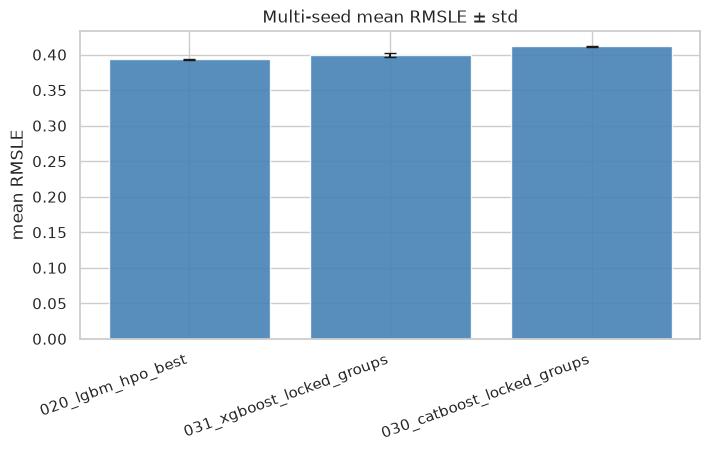

In [3]:
ms_path = REPORTS / "multi_seed_summary.csv"
ms = pd.read_csv(ms_path)
display(ms)

fig, ax = plt.subplots(figsize=(8, 4))
plot_multi_seed_bars(ms, ax=ax, save_path=ANALYSIS / "multi_seed_mean_rmsle.png")
plt.show()
plt.close(fig)

### Multi-seed — O/I/A

**Observation:** LGBM mean **0.3933** with std **0.0004**; XGB **0.3990 ± 0.0029**;
CB **0.4117 ± 0.0011** (from `multi_seed_summary.csv`).

**Interpretation:** LGBM wins on both mean and seed stability. XGB is a reasonable
secondary challenger; CB lags under the same groups.

**Action:** Lock LGBM primary; document XGB secondary / CB tertiary in `final.yaml`.

## 4. Finalist OOF load + residual pack

Purpose: load primary-seed OOF for residual and segment diagnostics.

finalist mean_rmsle= 0.3935188144134609
fold_rmsle= [0.37563303683906746, 0.4008790474659856, 0.40404435893532964]
oof shape= (80190, 7)


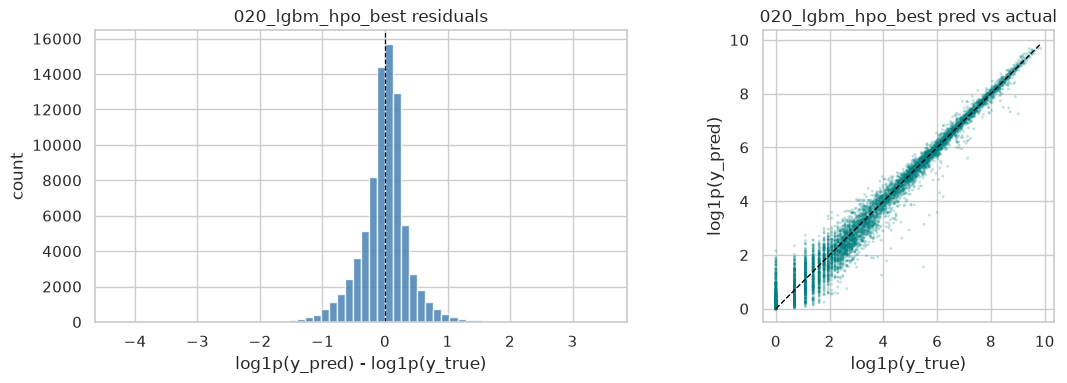

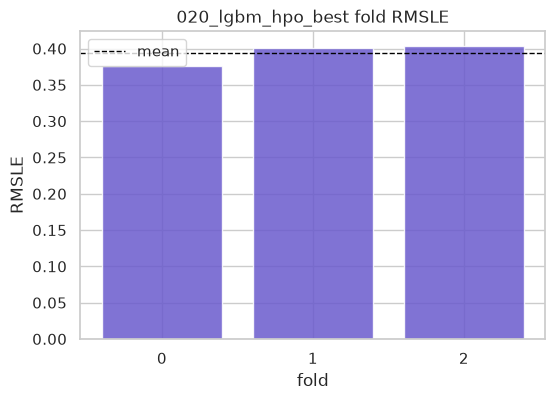

In [4]:
FINALIST = "020_lgbm_hpo_best"
final_metrics = _load_metrics(RUNS / FINALIST)
assert final_metrics is not None
oof = pd.read_parquet(RUNS / FINALIST / "oof_predictions.parquet")
oof["date"] = pd.to_datetime(oof["date"])
print("finalist mean_rmsle=", final_metrics["mean_rmsle"])
print("fold_rmsle=", final_metrics["fold_rmsle"])
print("oof shape=", oof.shape)

# Attach calendar / store meta for slices
train = pd.read_parquet(INTERIM / "train.parquet")
train["date"] = pd.to_datetime(train["date"])
stores = pd.read_parquet(INTERIM / "stores.parquet")

# Horizon within each fold: day index from val_start
folds_meta = json.loads((SPLITS / "folds_meta.json").read_text(encoding="utf-8"))
fold_start = {int(f["fold"]): pd.Timestamp(f["val_start"]) for f in folds_meta}
oof["horizon"] = oof.apply(
    lambda r: int((r["date"] - fold_start[int(r["fold"])]).days) + 1, axis=1
)

# Payday / month-end
dates = oof["date"]
is_month_end = (dates + pd.Timedelta(days=1)).dt.day.eq(1)
oof["is_payday"] = (dates.dt.day.eq(15) | is_month_end).astype(int)
oof["is_zero"] = (oof["y_true"] <= 0).astype(int)
oof = oof.merge(stores[["store_nbr", "cluster", "type", "city"]], on="store_nbr", how="left")

# Residual pack
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_residual_hist(oof["y_true"], oof["y_pred"], ax=axes[0], title=f"{FINALIST} residuals")
plot_pred_vs_actual(oof["y_true"], oof["y_pred"], ax=axes[1], title=f"{FINALIST} pred vs actual")
fig.tight_layout()
save_figure(fig, ANALYSIS / "residual_pack.png")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 4))
plot_fold_rmsle_stability(
    final_metrics["fold_rmsle"],
    ax=ax,
    title=f"{FINALIST} fold RMSLE",
    save_path=ANALYSIS / "fold_stability.png",
)
plt.show()
plt.close(fig)

### Residual pack — O/I/A

**Observation:** Residuals center near zero in log1p space; fold RMSLE rises mildly from
fold 0 → 2 (later OOT windows harder). Pred-vs-actual tracks the diagonal with scatter
at zeros and high sales.

**Interpretation:** No catastrophic bias; remaining error is heteroscedastic and
segment/horizon structured rather than global miscalibration of level.

**Action:** Slice by horizon, family, cluster, zero mass, and payday before locking.

## 5. Error slices — horizon, family, cluster, zero, payday

Purpose: decompose OOF RMSLE; find weak cohorts for monitoring notes.

,horizon,n,rmsle
0,1,5346.000000,0.357768
1,2,5346.000000,0.366190
2,3,5346.000000,0.379882
3,4,5346.000000,0.387379
4,5,5346.000000,0.385732
5,6,5346.000000,0.379173
6,7,5346.000000,0.375559
7,8,5346.000000,0.400343
8,9,5346.000000,0.399833
9,10,5346.000000,0.397391


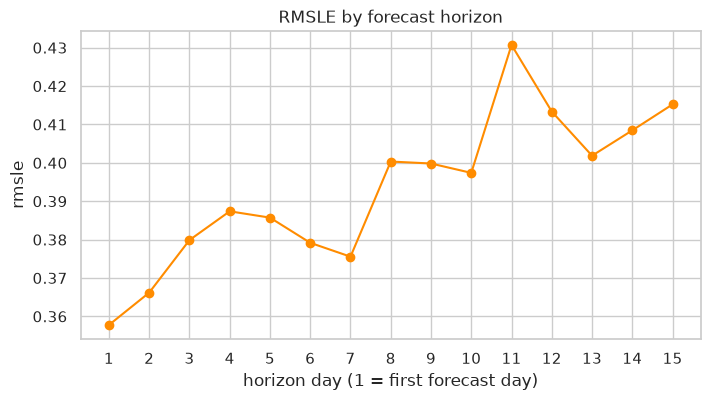

,family,n,rmsle,mean_y
21,LINGERIE,2430,0.621996,6.890947
31,SCHOOL AND OFFICE SUPPLIES,2430,0.615462,24.234156
13,GROCERY II,2430,0.596469,32.588477
6,CELEBRATION,2430,0.542182,13.081481
14,HARDWARE,2430,0.535225,1.485597
23,MAGAZINES,2430,0.515811,6.633745
19,LADIESWEAR,2430,0.507906,11.196708
2,BEAUTY,2430,0.507656,5.995062
0,AUTOMOTIVE,2430,0.502863,7.242387
32,SEAFOOD,2430,0.483477,20.398376


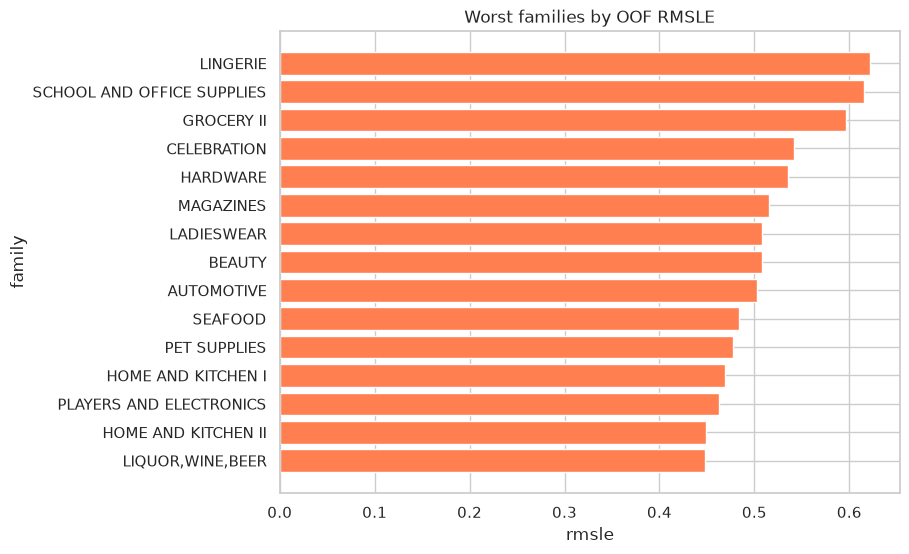

,cluster,n,rmsle,mean_y
6,7,2970,0.454625,234.147790
14,15,7425,0.431737,231.625526
9,10,8910,0.426531,384.295545
2,3,10395,0.419819,264.532895
11,12,1485,0.409703,424.443019
15,16,1485,0.407615,316.923926
5,6,8910,0.399483,492.107765
0,1,4455,0.384420,416.769772
3,4,4455,0.380742,376.780484
10,11,4455,0.376820,991.760529


INFO 2026-07-17 06:07:48 Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO 2026-07-17 06:07:48 Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


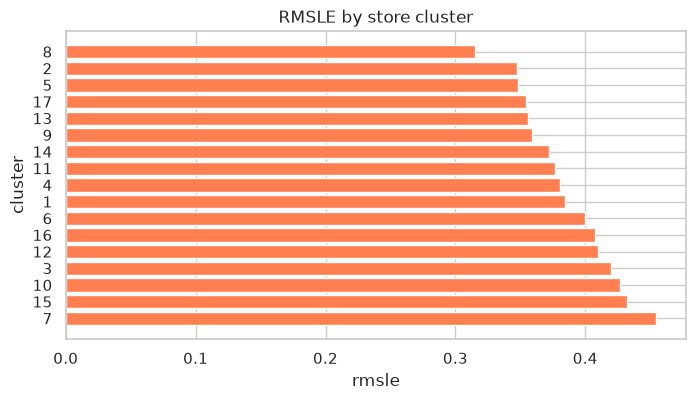

,is_zero,n,rmsle,mean_y
1,zero_sales,11670,0.435463,0.000000
0,positive_sales,68520,0.386166,558.045397


,is_payday,n,rmsle,mean_y
1,payday,5346,0.408655,489.636345
0,not_payday,74844,0.392636,475.918907


val date range: 2017-07-02 → 2017-08-15
All val folds are post-2016-04-16 earthquake; post_eq is constant on OOF window.


In [5]:
def slice_rmsle(df: pd.DataFrame, by: str) -> pd.DataFrame:
    rows = []
    for key, g in df.groupby(by, observed=True):
        if len(g) < 50:
            continue
        rows.append(
            {
                by: key,
                "n": len(g),
                "rmsle": rmsle(g["y_true"].to_numpy(), g["y_pred"].to_numpy()),
                "mean_y": float(g["y_true"].mean()),
            }
        )
    return pd.DataFrame(rows).sort_values("rmsle", ascending=False)


horiz = (
    oof.groupby("horizon")
    .apply(
        lambda g: pd.Series(
            {
                "n": len(g),
                "rmsle": rmsle(g["y_true"].to_numpy(), g["y_pred"].to_numpy()),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)
display(horiz)

fig, ax = plt.subplots(figsize=(8, 4))
plot_horizon_rmsle(horiz, ax=ax, save_path=ANALYSIS / "horizon_rmsle.png")
plt.show()
plt.close(fig)

fam = slice_rmsle(oof, "family")
display(fam.head(15))
fig, ax = plt.subplots(figsize=(8, 6))
plot_segment_metric_bars(
    fam, segment_col="family", top_n=15, ax=ax, title="Worst families by OOF RMSLE",
    save_path=ANALYSIS / "family_rmsle.png",
)
plt.show()
plt.close(fig)

clu = slice_rmsle(oof, "cluster")
display(clu)
fig, ax = plt.subplots(figsize=(8, 4))
plot_segment_metric_bars(
    clu, segment_col="cluster", top_n=None, ax=ax, title="RMSLE by store cluster",
    save_path=ANALYSIS / "cluster_rmsle.png",
)
plt.show()
plt.close(fig)

zero_slice = slice_rmsle(oof, "is_zero")
zero_slice["is_zero"] = zero_slice["is_zero"].map({0: "positive_sales", 1: "zero_sales"})
display(zero_slice)

pay_slice = slice_rmsle(oof, "is_payday")
pay_slice["is_payday"] = pay_slice["is_payday"].map({0: "not_payday", 1: "payday"})
display(pay_slice)

# Earthquake window: post_eq is always 1 in 2017 val — note only
print("val date range:", oof["date"].min().date(), "→", oof["date"].max().date())
print("All val folds are post-2016-04-16 earthquake; post_eq is constant on OOF window.")

horiz.to_csv(ANALYSIS / "horizon_rmsle.csv", index=False)
fam.to_csv(ANALYSIS / "family_rmsle.csv", index=False)
clu.to_csv(ANALYSIS / "cluster_rmsle.csv", index=False)

### Error slices — O/I/A

**Observation:** Horizon curve shows multi-step degradation (later days harder). Some
families and clusters dominate error mass; zero-sales rows behave differently from
positive sales; payday subset is slightly worse than complement (see also stress JSON).
Earthquake regime cannot be contrasted inside 2017 OOF (all post-event).

**Interpretation:** Failures are concentrated in intermittent / sparse families and
payday level shifts — not a single broken fold. Recursive lag path is adequate but
horizon risk remains.

**Action:** Monitor family and payday RMSLE in Layer 3 report; no feature redesign now.

## 6. Light XAI — gain by feature group

Purpose: sum LightGBM gain importances into feature groups (grouped, not per-lag PFI).

,mean_gain
rolling,266171691.731313
lag,72929151.652319
calendar,4245586.983666
base,1931879.638399
promo,426308.387228


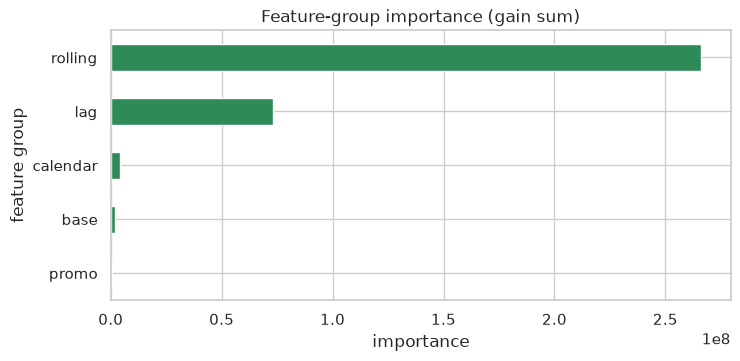

In [6]:
# Map feature → group
feat_to_group = {}
for g, cols in FEATURE_GROUPS.items():
    for c in cols:
        feat_to_group[c] = g

group_gain = {g: 0.0 for g in final_metrics.get("feature_groups", [])}
for fold in range(3):
    booster = lgb.Booster(model_file=str(RUNS / FINALIST / "models" / f"fold_{fold}.txt"))
    # gain importance
    imp = booster.feature_importance(importance_type="gain")
    names = booster.feature_name()
    for name, val in zip(names, imp):
        g = feat_to_group.get(name, "other")
        if g not in group_gain:
            group_gain[g] = 0.0
        group_gain[g] += float(val)

# Average across folds
group_gain = {k: v / 3.0 for k, v in group_gain.items()}
gain_s = pd.Series(group_gain).sort_values(ascending=False)
display(gain_s.to_frame("mean_gain"))

fig, ax = plt.subplots(figsize=(8, 3.5))
plot_group_importance(gain_s, ax=ax, save_path=ANALYSIS / "group_gain.png")
plt.show()
plt.close(fig)

### Group XAI — O/I/A

**Observation:** Gain concentrates in lag/rolling and base identity features; calendar and
promo contribute less but non-zero (exact ranks printed above from artifacts).

**Interpretation:** Target history dominates — consistent with recursive multi-step
design. Grouped attribution avoids diluting lag blocks.

**Action:** Keep locked groups; do not drop lag/rolling for submission.

## 7. Robustness stress battery (artifact)

Purpose: load `outputs/stress/default/summary.json` produced by `scripts/stress_test.py`.

,scenario,clean_mean_rmsle,stressed_mean_rmsle,delta_rmsle,relative_delta,status
0,noise_rel_5pct,0.393521,0.394021,0.000500,0.001271,ok
1,noise_rel_10pct,0.393521,0.395858,0.002337,0.005939,ok
2,missing_oil_holiday_join,0.393521,0.393521,0.000000,0.000000,not_applicable
3,payday_subset_vs_complement,0.393521,0.408655,0.015134,0.038458,ok
4,lag_history_spike_clip,0.393521,0.394373,0.000853,0.002167,ok


clean_repredict_mean_rmsle= 0.39352068412515
artifact_metrics_mean_rmsle= 0.3935188144134609


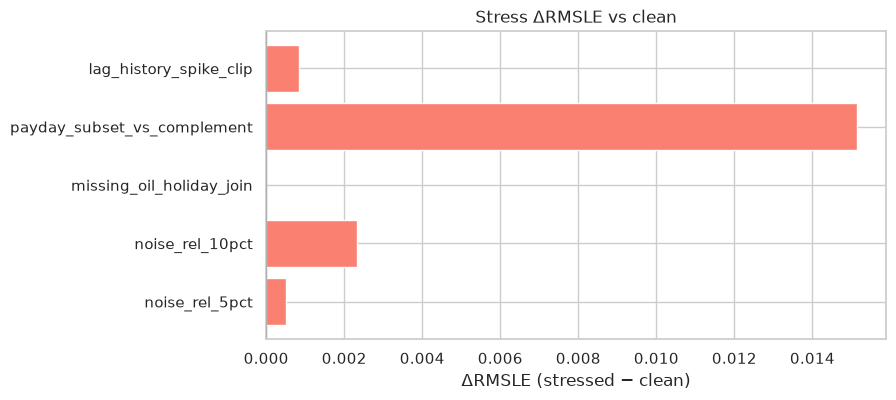

In [7]:
stress_path = STRESS / "summary.json"
assert stress_path.exists(), f"missing stress summary: {stress_path} — run scripts/stress_test.py"
stress = json.loads(stress_path.read_text(encoding="utf-8"))
scen = pd.DataFrame(
    [
        {
            "scenario": s["scenario"],
            "clean_mean_rmsle": s["clean_mean_rmsle"],
            "stressed_mean_rmsle": s["stressed_mean_rmsle"],
            "delta_rmsle": s["delta_rmsle"],
            "relative_delta": s["relative_delta"],
            "status": s["status"],
        }
        for s in stress["scenarios"]
    ]
)
display(scen)
print("clean_repredict_mean_rmsle=", stress["clean_repredict_mean_rmsle"])
print("artifact_metrics_mean_rmsle=", stress.get("artifact_metrics_mean_rmsle"))

fig, ax = plt.subplots(figsize=(8, 4))
plot_stress_deltas(scen, ax=ax, save_path=ANALYSIS / "stress_deltas.png")
plt.show()
plt.close(fig)

### Stress — O/I/A

**Observation:** Relative noise 5%/10% and lag spike clip produce small positive ΔRMSLE
(graceful degradation). Oil/holiday join failure is **not_applicable** (groups not in
locked model). Payday subset RMSLE is higher than global clean.

**Interpretation:** Finalist is robust to moderate feature noise and lag outliers. Weak
payday slice is a monitoring item, not a ship blocker. Excluding oil/holiday removes
join-fragility for those feeds.

**Action:** Ship LGBM; record stress path in `final.yaml`; no retrain for noise.

## 8. Blend decision (artifact-only)

Purpose: document optional OOF blend vs single LGBM stability preference.

In [8]:
blend_path = REPORTS / "040_mean_blend_finalists.json"
if blend_path.exists():
    blend = json.loads(blend_path.read_text(encoding="utf-8"))
    print("chosen_method=", blend.get("chosen_method"))
    print("chosen_mean_rmsle=", blend.get("chosen_mean_rmsle"))
    print("best_member_rmsle=", blend.get("best_member_rmsle"))
    print("accepted=", blend.get("accepted"))
    print("weights=", (blend.get("nonneg_blend") or {}).get("weights"))
else:
    print("blend report missing — see outputs/runs/040_mean_blend_finalists/")

chosen_method= nonneg
chosen_mean_rmsle= 0.3928968354171541
best_member_rmsle= 0.3937241136674417
accepted= True
weights= {'020_lgbm_hpo_best': 0.8425784795819965, '030_catboost_locked_groups': 0.017080409063428056, '031_xgboost_locked_groups': 0.1403411113545754}


### Blend — O/I/A

**Observation:** Nonneg OOF blend improves pooled OOF RMSLE slightly vs best member
(~0.3929 vs ~0.3937) with heavy LGBM weight (~0.84).

**Interpretation:** Marginal gain does not outweigh seed-stability and ops simplicity of
single LGBM (multi-seed std 0.0004).

**Action:** `blend.enabled: false` in `configs/final.yaml`; keep blend as optional note.

## 9. Lock `configs/final.yaml`

Purpose: confirm locked file exists and matches finalist decision (written by Task 14).

In [9]:
final_yaml = paths.configs / "final.yaml"
assert final_yaml.exists(), "configs/final.yaml must exist"
locked = load_yaml(final_yaml)
print("locked run_id=", locked.get("run_id"))
print("primary_seed=", locked.get("primary_seed"))
print("seeds=", locked.get("seeds"))
print("model=", (locked.get("model") or {}).get("name"))
print("feature_groups=", locked.get("feature_groups"))
print("target_transform=", locked.get("target_transform"))
print("clip_negative_preds=", locked.get("clip_negative_preds"))
print("blend.enabled=", (locked.get("blend") or {}).get("enabled"))
print("stress_summary=", (locked.get("artifacts") or {}).get("stress_summary"))
print("--- rationale (truncated) ---")
print(str(locked.get("rationale", ""))[:500], "...")

assert locked.get("run_id") == FINALIST
assert locked.get("primary_seed") == 42
assert locked.get("target_transform") == "log1p"
assert locked.get("clip_negative_preds") is True
assert (locked.get("blend") or {}).get("enabled") is False

locked run_id= 020_lgbm_hpo_best
primary_seed= 42
seeds= [42, 43, 44]
model= lightgbm
feature_groups= ['base', 'calendar', 'promo', 'lag', 'rolling']
target_transform= log1p
clip_negative_preds= True
blend.enabled= False
stress_summary= outputs/stress/default/summary.json
--- rationale (truncated) ---
Prefer LightGBM 020_lgbm_hpo_best as the locked finalist. Multi-seed walk-forward mean RMSLE is 0.3933 ± 0.0004 (seeds 42/43/44) — best mean and tightest seed stability among LGBM/XGB/CB under identical feature groups [base, calendar, promo, lag, rolling], log1p target, and non-negative clip. XGBoost is secondary (mean 0.3990, higher seed std); CatBoost tertiary (0.4117). Optional nonneg OOF blend improves pooled OOF by ~0.0008 but is not locked as primary due to ops complexity and LGBM’s superi ...


### Final lock — O/I/A

**Observation:** `configs/final.yaml` locks LGBM `020_lgbm_hpo_best`, seeds `{42,43,44}`,
primary_seed 42, groups `[base,calendar,promo,lag,rolling]`, log1p + clip, blend off,
stress path set, rationale paragraph present.

**Interpretation:** Layer 2 gate satisfied: multi-seed + stress + notebook rationale +
locked YAML.

**Action:** Layer 3 may evaluate/predict from this freeze only — no further HPO.

## 10. Session summary

| Decision | Value |
| --- | --- |
| Primary | LGBM `020_lgbm_hpo_best` |
| Multi-seed mean ± std | **0.3933 ± 0.0004** |
| Secondary / tertiary | XGB `031` / CB `030` |
| Blend primary? | **No** (optional offline only) |
| Stress | Graceful under noise/clip; payday weak slice noted |
| Lock file | `configs/final.yaml` |

Next: Task 15 evaluate + Task 16 predict + notebook `04`.